## Tensile Stress-Strain Curve Analysis for 3D-Printed Polymers
*Code written by Francis Sanguyo*

*Date: April 21-28, 2026*

*MATSE 121.02 LAB Post-Lab 5*

*Mechanical Properties of 3D-Printed Poly(Lactic Acid) (PLA), Poly(Ethylene Terephthalate) Glycol (PETG), and Thermoplastic Polyurethane (TPU) Under Tensile Loading*


**Outline:**



1. Import packages

2. Read the CSV data files
 - Remove the final few entries of each stress and strain list as these entries occur after slippage of grips or fracture of the material.

3. Calculate the stress-strain curve (engineering and true values) for each material.

 - 3.1 Calculate the cross-sectional area of each material.

$(Area) = (thickness) \times (width)$

 - 3.2 Compute the engineering stress and strain.

$\sigma = \dfrac{F}{A_0}, \qquad A_0 = \text{initial cross-sectional area}$

$\varepsilon = \dfrac{\Delta L}{L_0}, \qquad L_0 = \text{initial length}$

 - 3.3 Compute the true stress and strain

$\varepsilon_T = \ln(1 + \varepsilon)$

$\sigma_T = \sigma(1 + \varepsilon)$

4. Plot the stress-strain curves of the materials tested

 - 4.1 Provide initial plots of the engineering stress-strain curves.

 - 4.2 Provide initial plots for the true stress-strain curves.

 - 4.3. Save the engineering and true stress and strain values per material as CSV files.


5. Compute the different mechanical properties ($E$, $\sigma_Y$, $\sigma_{UTS}$, $\sigma_F$, $\% EL%$, $U_r$ and $U_t$) of the polymer samples based on the engineering stress-strain curves.

 - 5.1. Using linear regression and 0.2% method, get the elastic and plastic regions of each curve.

 - 5.2. From the elastic region, obtain the elastic modulus ($E$), yield strength ($\sigma_Y$), and modulus of resilience ($U_r$) of each material.

*For each engineering stress-strain curve, determine the first equation of the line σ = A + Bε (A = intercept, B = slope) which closely fits all the points in between of these boundaries.*

*For the 0.2% method, get the second equation of the line σ = A + B(ε - 0.002), or more simply  σ = (A - 0.002B) + Bε or just σ = C + Dε which has been translated to the right by 2% strain.*

*Then using linear interpolation find the strain εY around the end of the linear region (within 20%) where the difference function D(ε) = becomes zero and switches signs*

 - 5.3. Find the peak(s) and fracture point of each curve within the plastic region of each curve.

 - 5.4. From the plastic region, obtain the ultimate tensile strength ($\sigma_{UTS}$), fracture strength ($\sigma_F$), percent elongation ($\%EL$), and toughness ($U_t$) of each material.

 - 5.5 - Special: Compute the True Stress for Zero Plastic Strain

 - 5.6. Save the computed mechanical properties of each polymer to a CSV file.


6. Model the elastic and early plastic region of each engineering stress-strain curve using the Ramberg-Osgood equation.

$\varepsilon = \varepsilon_E + \varepsilon_P$

$\varepsilon = \dfrac{\sigma}{E} + K(\dfrac{\sigma}{E})^{n}$

 - 6.1. Get the Ramberg-Osgood parameters $K$ and $n$ which best fit the elastic and early plastic regions.

 - 6.2. Plot the predicted values of the Ramberg-Osgood equation alongside the engineering stress-strain plots

 - 6.3. Save data on the Ramberg-Osgood equation to a CSV file.


### 1. Import packages

Load up the necessary packages for this program.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import linregress
from scipy.integrate import simpson
from math import log10

### 2. Read the CSV data files
Read the CSV data files assigned to polymer samples tested and their respective displacement-force curves in the folder "Readable_Data_Files".

In [2]:
# Read the CSV data file with the polymer samples' information.
str_fileLoc_polymerSamplesInfo = "./Readable_Data_Files/UTMdata_samples_info_summary.csv"
DF_polymerSamplesInfo = pd.read_csv(str_fileLoc_polymerSamplesInfo)
print("Read data on information regarding the polymer samples:")
print(DF_polymerSamplesInfo.head())
print(DF_polymerSamplesInfo.tail())

# Split the columns of relevance in the dataframe into lists.
int_sample_count = DF_polymerSamplesInfo.shape[0]
list_sample_names = DF_polymerSamplesInfo["Sample"].to_list()
list_sample_plotColors = DF_polymerSamplesInfo["Plot Color"].to_list()
list_sample_strainRates = DF_polymerSamplesInfo["Strain Rate (mm/min)"].to_list()
list_sample_thickness = DF_polymerSamplesInfo["Thickness (mm)"].to_list()
list_sample_width = DF_polymerSamplesInfo["Width (mm)"].to_list()
list_sample_length = DF_polymerSamplesInfo["Length Between Grips (mm)"].to_list()
list_sample_density = DF_polymerSamplesInfo["Density (g/cm3)"].to_list()

# Read the CSV data file with the displacement-force data of the UTM per polymer sample.
str_fileLoc_dispForce_PLA = "./Readable_Data_Files/UTMdata_disp_force_PLA.csv"
str_fileLoc_dispForce_PETG = "./Readable_Data_Files/UTMdata_disp_force_PETG.csv"
str_fileLoc_dispForce_TPU = "./Readable_Data_Files/UTMdata_disp_force_TPU_trial3.csv"
list_fileLocs_dispForce = [str_fileLoc_dispForce_PLA, str_fileLoc_dispForce_PETG, str_fileLoc_dispForce_TPU]
listDFs_UTMdata_dispForce = [pd.read_csv(str_fileLoc) for str_fileLoc in list_fileLocs_dispForce]
print("Read data on the displacement-force graphs from the UTM for each polymer sample:")
print(listDFs_UTMdata_dispForce[0].head())
print(listDFs_UTMdata_dispForce[0].tail())

# Split each data frame into two lists corresponding to displacement (in mm) and tensile force (in N) data.
list_UTMdata_displacement = [DF_UTMdata["Displacement (mm)"].to_list() for DF_UTMdata in listDFs_UTMdata_dispForce]
list_UTMdata_tensileForce = [DF_UTMdata["Tensile Force (N)"].to_list() for DF_UTMdata in listDFs_UTMdata_dispForce]

Read data on information regarding the polymer samples:
  Sample                          Full Name Sample Color Plot Color  \
0    PLA                  Poly(lactic acid)          red    #d1482e   
1   PETG  Polyethylene terephthalate glycol         blue    #522bd4   
2    TPU         Thermoplastic polyurethane       yellow    #d9b313   

   Filament Type  % Infill Infill Pattern  Strain Rate (mm/min)  \
0       Esun PLA       100    rectilinear                    20   
1   Generic PETG       100    rectilinear                    20   
2  SainSmart TPU       100    rectilinear                    20   

   Thickness (mm)  Width (mm)  Length Between Grips (mm)  \
0               3          13                        100   
1               3          13                        100   
2               3          13                        100   

   Length of Entire Sample (mm)  Density (g/cm3)  
0                           169             1.27  
1                           169             1.2

### Additional - Remove the final few entries of each stress and strain list as these entries occur after slippage of grips or fracture of the material.


In [3]:
list_indices_to_exclude = [-4, -7, -5]
list_UTMdata_displacement = [UTMdata_displacement[0:index] for UTMdata_displacement, index in zip(list_UTMdata_displacement, list_indices_to_exclude)]
list_UTMdata_tensileForce = [UTMdata_tensileForce[0:index] for UTMdata_tensileForce, index in zip(list_UTMdata_tensileForce, list_indices_to_exclude)]


### 3. Calculate the stress-strain curve (engineering and true values) for each material.

#### 3.1 Calculate the cross-sectional area of each material.
Use the formula $(Area) = (thickness) \times (width)$ to get the cross-sectional area in square mm of each material sample. Assume the sample has a rectangular, uniform cross-sectional area in between the grips of the UTM.

In [4]:
# Calculate the cross-sectional areas of each material sample, then store as a list
list_sample_crossSectionalArea = (np.array(list_sample_thickness)*np.array(list_sample_width)).tolist()
DF_polymerSamplesInfo["Cross-Sectional Area (mm²)"] = list_sample_crossSectionalArea

#### 3.2 Compute the engineering stress and strain.

Given data is the displacement $x = \Delta L$ (in mm) of the material from its original length and the applied tensile force $F$ (in N) from the UTM on both grips of the material.

To convert it to engineering stress $\sigma$ and strain $\varepsilon$, use the following formulas after conversion to metric units (that is, with the conversion factor 1000 mm = 1 m):

$\sigma = \dfrac{F}{A_0}, \qquad A_0 = \text{initial cross-sectional area}$

$\varepsilon = \dfrac{\Delta L}{L_0}, \qquad L_0 = \text{initial length}$

In [5]:
# Compute engineering stress and strain for each material
list_UTMdata_stressEngg = []
list_UTMdata_strainEngg = []
for UTMdata_displacement, UTMdata_tensileForce, sample_crossSectionalArea, sample_length in zip(list_UTMdata_displacement, list_UTMdata_tensileForce, list_sample_crossSectionalArea, list_sample_length):
    UTMdata_stressEngg = (np.array(UTMdata_tensileForce)/(sample_crossSectionalArea*(1/1000)**2)).tolist()
    UTMdata_strainEngg = (np.array(UTMdata_displacement)/sample_length).tolist()
    list_UTMdata_stressEngg.append(UTMdata_stressEngg)
    list_UTMdata_strainEngg.append(UTMdata_strainEngg)


#### 3.3 Compute the true stress and strain
Convert the calculated values for engineering stress $\sigma$ and strain $\varepsilon$ into their true values $\sigma_T$ and $\varepsilon_T$ which do not assume constant cross-sectional area. Use the following formulas (derived via integration) to perform this computation:

$\varepsilon_T = \ln(1 + \varepsilon)$

$\sigma_T = \sigma(1 + \varepsilon)$



In [6]:
# Compute the true stress and strain for each material
list_UTMdata_stressTrue = []
list_UTMdata_strainTrue = []
for UTMdata_stressEngg, UTMdata_strainEngg in zip(list_UTMdata_stressEngg, list_UTMdata_strainEngg):
    UTMdata_strainTrue = (np.log(1 + np.array(UTMdata_strainEngg))).tolist()
    UTMdata_stressTrue = (np.array(UTMdata_stressEngg)*np.add(UTMdata_strainEngg, 1)).tolist()
    list_UTMdata_stressTrue.append(UTMdata_stressTrue)
    list_UTMdata_strainTrue.append(UTMdata_strainTrue)

## 4. Plot the stress-strain curves of the materials tested

Provide initial plots for the stress-strain curves of the different polymeric materials tested with engineering values and true values.

### 4.1 Provide initial plots of the engineering stress-strain curves.


(0.0, 52.0)

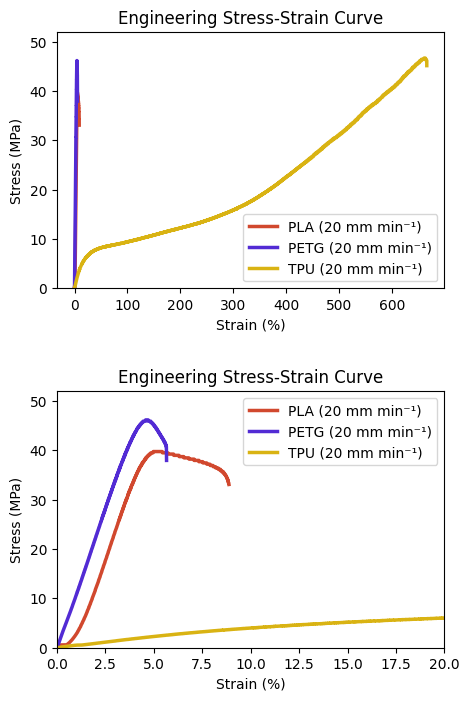

In [9]:
# Set plotting parameters
param_plot_xlabel = "Strain (%)"
param_plot_ylabel = "Stress (MPa)"
param_plot_linewidth = 2.5

# Plot the engineering stress (in MPa; y-axis) against engineering strain (in %; x-axis)
figure, (ax1, ax2) = plt.subplots(2, 1, figsize = (5, 8))
plt.subplots_adjust(hspace = 0.4)
for UTMdata_stressEngg, UTMdata_strainEngg, plotColor, name, strainRate in zip(list_UTMdata_stressEngg, list_UTMdata_strainEngg, list_sample_plotColors, list_sample_names, list_sample_strainRates):
    ax1.plot(np.array(UTMdata_strainEngg)*100, np.array(UTMdata_stressEngg)/10**6, label = f"{name} ({strainRate} mm min⁻¹)", linewidth = param_plot_linewidth, color = plotColor)
    ax2.plot(np.array(UTMdata_strainEngg)*100, np.array(UTMdata_stressEngg)/10**6, label = f"{name} ({strainRate} mm min⁻¹)", linewidth = param_plot_linewidth, color = plotColor)
for axis in (ax1, ax2):
    axis.set(xlabel = param_plot_xlabel, ylabel = param_plot_ylabel)
    axis.legend()
    axis.set_title("Engineering Stress-Strain Curve")

# Set different x-limits but the same y-limit for each plot
ax2.set_xlim(0, 20)
ax1.set_ylim(0, 52)
ax2.set_ylim(0, 52)


### 4.2 Provide initial plots for the true stress-strain curves.

(0.0, 52.0)

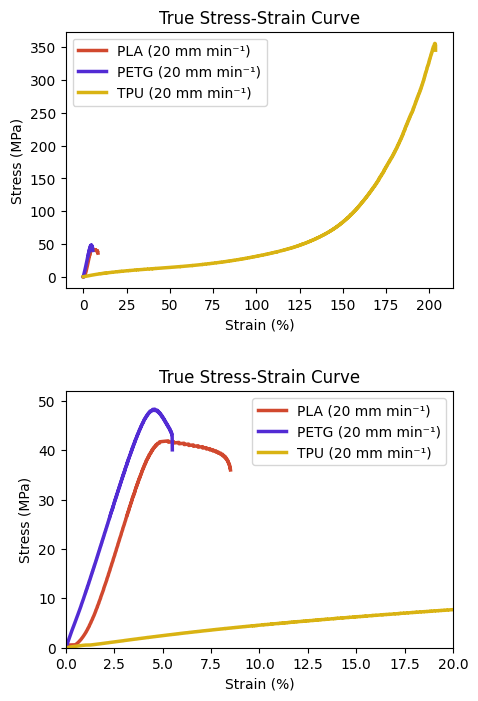

In [10]:
# Set plotting parameters
param_plot_xlabel = "Strain (%)"
param_plot_ylabel = "Stress (MPa)"
param_plot_linewidth = 2.5

# Plot the engineering stress (in MPa; y-axis) against engineering strain (in %; x-axis)
figure, (ax1, ax2) = plt.subplots(2, 1, figsize = (5, 8))
plt.subplots_adjust(hspace = 0.4)
for UTMdata_stressTrue, UTMdata_strainTrue, plotColor, name, strainRate in zip(list_UTMdata_stressTrue, list_UTMdata_strainTrue, list_sample_plotColors, list_sample_names, list_sample_strainRates):
    ax1.plot(np.array(UTMdata_strainTrue)*100, np.array(UTMdata_stressTrue)/10**6, label = f"{name} ({strainRate} mm min⁻¹)", linewidth = param_plot_linewidth, color = plotColor)
    ax2.plot(np.array(UTMdata_strainTrue)*100, np.array(UTMdata_stressTrue)/10**6, label = f"{name} ({strainRate} mm min⁻¹)", linewidth = param_plot_linewidth, color = plotColor)
for axis in (ax1, ax2):
    axis.set(xlabel = param_plot_xlabel, ylabel = param_plot_ylabel)
    axis.legend()
    axis.set_title("True Stress-Strain Curve")
ax2.set_xlim(0, 20)
ax2.set_ylim(0, 52)

### 4.3. Save the engineering and true stress and strain values per material as CSV files.

In [13]:
listDFs_UTMdata_StressStrainEngg = []
listDFs_UTMdata_StressStrainTrue = []

for sampleName, strainRate, stressEngg, strainEngg, stressTrue, strainTrue in zip(list_sample_names, list_sample_strainRates, list_UTMdata_stressEngg, list_UTMdata_strainEngg, list_UTMdata_stressTrue, list_UTMdata_strainTrue):
    str_fileName_engg = f"./Output_Data_Files/UTMdata_stressStrainEngg_{sampleName}_{strainRate:d}mm-min.csv"
    str_fileName_true = f"./Output_Data_Files/UTMdata_stressStrainTrue_{sampleName}_{strainRate:d}mm-min.csv"

    DF_UTMdata_stressStrainEngg = pd.DataFrame({"Engineering Strain (unitless)": strainEngg,
                                                    "Engineering Stress (Pa)": stressEngg})
    DF_UTMdata_stressStrainTrue = pd.DataFrame({"True Strain (unitless)": strainTrue,
                                                "True Stress (Pa)": stressTrue})

    # Save dataframes for engineering and true stress and strain as CSV files under the folder "Output_Data_Files"
    DF_UTMdata_stressStrainEngg.to_csv(str_fileName_engg, index = False)
    DF_UTMdata_stressStrainTrue.to_csv(str_fileName_true, index = False)

    # Append dataframes to the existing lists
    listDFs_UTMdata_StressStrainEngg.append(DF_UTMdata_stressStrainEngg)
    listDFs_UTMdata_StressStrainTrue.append(DF_UTMdata_stressStrainTrue)


## 5. Compute the different mechanical properties ($E$, $\sigma_Y$, $\sigma_{UTS}$, $\sigma_F$, $\% EL%$, $U_r$ and $U_t$) of the polymer samples based on the engineering stress-strain curves.

### 5.1. Using linear regression and 0.2% method, get the elastic and plastic regions of each curve.

In [14]:
# From manual inspection of the engineering stress-strain curve, regions selected for linear regression in determining the elastic region were assigned to be as follows:
# Linear Region (strain in %)
# PLA:  1.05% - 4.26%
# PETG: 0.00% - 3.93%
# TPU:  0.00% - 15.02%
list_UTMdata_linearRegionStart = [0.0105, 0.00, 0.00]
list_UTMdata_linearRegionEnd = [0.0426, 0.0393, 0.1502]

# For each engineering stress-strain curve, determine the first equation of the line σ = A + Bε (A = intercept, B = slope) which closely fits all the points in between of these boundaries.
list_UTMdata_linregressIntA = []
list_UTMdata_linregressSlopeB = []
for strainEngg, stressEngg, linearStrainStart, linearStrainEnd in zip(list_UTMdata_strainEngg, list_UTMdata_stressEngg, list_UTMdata_linearRegionStart, list_UTMdata_linearRegionEnd):
    arr_strainEngg = np.array(strainEngg)
    list_indices_to_include = (np.where((arr_strainEngg > linearStrainStart) & (arr_strainEngg < linearStrainEnd))[0]).tolist()
    #print(f"Indices included: {list_indices_to_include}")

    arr_strainEnggLinear = arr_strainEngg[list_indices_to_include]
    arr_stressEnggLinear = (np.array(stressEngg))[list_indices_to_include]
    #print(f"Strain: {arr_strainEnggLinear}\nStress: {arr_stressEnggLinear}")

    obj_linregressLinear = linregress(arr_strainEnggLinear, arr_stressEnggLinear)
    val_linregressIntA = float(obj_linregressLinear.intercept)
    val_linregressSlopeB = float(obj_linregressLinear.slope)
    #print(f"Intercept: {val_linregressIntA} \nSlope: {val_linregressSlopeB}")

    list_UTMdata_linregressIntA.append(val_linregressIntA)
    list_UTMdata_linregressSlopeB.append(val_linregressSlopeB)

# Create a lambda function for the first equation of the line σ = A + Bε (for plotting later)
list_func_linregressStress = []
for intA, slopeB in zip(list_UTMdata_linregressIntA, list_UTMdata_linregressSlopeB):
    func_linregressStress = lambda strain: intA + slopeB * strain
    list_func_linregressStress.append(func_linregressStress)

# For the 0.2% method, get the second equation of the line σ = A + B(ε - 0.002), or more simply  σ = (A - 0.002B) + Bε or just σ = C + Dε which has been translated to the right by 2% strain.
list_UTMdata_Point2Method_linregressIntC = [intA - 0.002*slopeB for intA, slopeB in zip(list_UTMdata_linregressIntA, list_UTMdata_linregressSlopeB)]
list_UTMdata_Point2Method_linregressSlopeD = list_UTMdata_linregressSlopeB.copy() # copy since lists are mutable

# Create a lambda function for the second equation of the line σ = (A - 0.02B) + Bε (for plotting later)
list_func_Point2Method_linregressStress = []
for intC, slopeD in zip(list_UTMdata_Point2Method_linregressIntC, list_UTMdata_Point2Method_linregressSlopeD):
    func_Point2Method_linregressStress = lambda strain: intC + slopeD * strain
    list_func_Point2Method_linregressStress.append(func_Point2Method_linregressStress)

print(f"Intercept A {list_UTMdata_linregressIntA}\n"
      f"SlopeB {list_UTMdata_linregressSlopeB}\n"
      f"Intercept C {list_UTMdata_Point2Method_linregressIntC}\n"
      f"SlopeD {list_UTMdata_Point2Method_linregressSlopeD}")


# To determine where the yield point is, first get the difference between the experimental stress values and the stress values computed from the second equation of the line σ = C + Dε.
# Let this function be D(ε) = σ(expt) - (C + Dε)
list_UTMdata_differenceFunction = [(np.array(stressEngg) - ((intC + slopeD*np.array(strainEngg)))).tolist() for stressEngg, strainEngg, intC, slopeD in zip(list_UTMdata_stressEngg, list_UTMdata_strainEngg, list_UTMdata_Point2Method_linregressIntC, list_UTMdata_Point2Method_linregressSlopeD)]

# Then using linear interpolation find the strain εY around the end of the linear region (within 20%) where the difference function D(ε) becomes zero and switches signs
list_UTMdata_rangeSearchYieldPointStart = [0.80*linregressEnd for linregressEnd in list_UTMdata_linearRegionEnd]
list_UTMdata_rangeSearchYieldPointEnd = [1.20*linregressEnd for linregressEnd in list_UTMdata_linearRegionEnd]
list_UTMdata_strainYield = []
list_UTMdata_stressYield = []

for strainEngg, differenceFunc, searchStart, searchEnd, intC, slopeD in zip(list_UTMdata_strainEngg, list_UTMdata_differenceFunction, list_UTMdata_rangeSearchYieldPointStart, list_UTMdata_rangeSearchYieldPointEnd, list_UTMdata_Point2Method_linregressIntC, list_UTMdata_Point2Method_linregressSlopeD):
    # Just include the points within the search range of the yield point (that is, 20% around the marked end for the linear region)
    arr_strainEngg = np.array(strainEngg)
    arr_differenceFunc = np.array(differenceFunc)
    list_indices_to_include = (np.where((arr_strainEngg > searchStart) & (arr_strainEngg < searchEnd))[0]).tolist()

    arr_strainSearch = arr_strainEngg[list_indices_to_include]
    arr_diffFuncSearch = arr_differenceFunc[list_indices_to_include]

    # Figure out the index where the sign of the difference function changes. Search starting from the highest strain of the search range. Do this by comparing the signs of consecutive terms and finding where they switch.
    arr_strainSearch_rev = arr_strainSearch[::-1]
    arr_diffFuncSearch_rev = arr_diffFuncSearch[::-1]
    arr_signs_diffFuncSearch_rev = np.sign(arr_diffFuncSearch_rev)
    index1 = 0
    index2 = 1
    for index in range(len(arr_signs_diffFuncSearch_rev)-1):
        sign1 = arr_signs_diffFuncSearch_rev[index]
        sign2 = arr_signs_diffFuncSearch_rev[index+1]
        if sign1 != sign2: # Detect change in the sign of the difference function
            index1 = index
            index2 = index + 1
            break

    # Estimate the strain where the sign changes (where D(ε) becomes zero). This is the strain at yield
    # From the point-slope form of the line
    # D - D1 = m(ε - ε1), where m = (D2 - D1)/(ε2 - ε1)
    # Then set D = 0 and ε = εY
    # -D1 = (D2 - D1)/(ε2 - ε1) * (εY - ε1)
    # εY = ε1 - D1*(ε2 - ε1)/(D2 - D1)
    val_strain1, val_strain2 = arr_strainSearch_rev[index1], arr_strainSearch_rev[index2]
    val_diff1, val_diff2 = arr_diffFuncSearch_rev[index1], arr_diffFuncSearch_rev[index2]
    strainYield = val_strain1 - val_diff1*(val_strain2 - val_strain1)/(val_diff2 - val_diff1)

    # Finally, compute the yield stress by plugging εY into the equation (σY) = C + D(εY) of the second line. This is the stress where the second line intersects the original engineering stress-strain curve.
    stressYield = intC + slopeD*strainYield

    # Append values to the list of yield stress and strain values
    list_UTMdata_strainYield.append(strainYield)
    list_UTMdata_stressYield.append(stressYield)


Intercept A [-9599706.354308192, -292235.89358884096, 383483.9766105418]
SlopeB [1096098259.1207404, 1124582084.341708, 34610935.02118148]
Intercept C [-11791902.872549672, -2541400.0622722567, 314262.10656817886]
SlopeD [1096098259.1207404, 1124582084.341708, 34610935.02118148]


### 5.2. From the elastic region, obtain the elastic modulus ($E$), yield strength ($\sigma_Y$), and modulus of resilience ($U_r$) of each material.

In [16]:
# From the code block in 5.1:
# Elastic Region:    ε in interval [0, εY]
# Elastic Modulus:   E = Slope B   (for the first equation of the line)
# Yield Strength:    σY = σY       (stress value for intersection with second equation of line)
# Strain at Yield:   εY = εY       (strain value for intersection with second equation of line)
# Modulus of Resilience:  Ur = \int{0}{εY}{σ_expt*dε_expt}    (area of the elastic region)

list_UTMresult_elasticModulus = list_UTMdata_linregressSlopeB.copy()
list_UTMresult_yieldStrength = list_UTMdata_stressYield.copy()
list_UTMresult_strainAtYield = list_UTMdata_strainYield.copy()

# To compute the integral for the modulus of resilience, perform numerical integration using Simpson's rule from ε = 0, to ε = εY on the engineering stress-strain curve.
# Note that the units for modulus of resilience Ur is in J/m**3, which is equivalent to N/m**2 or Pa
list_UTMresult_modulusOfResilience = []
for stressEngg, strainEngg, strainYield in zip(list_UTMdata_stressEngg, list_UTMdata_strainEngg, list_UTMdata_strainYield):
    # Just include the points where strain is between 0 and εY
    arr_strainEngg = np.array(strainEngg)
    arr_stressEngg = np.array(stressEngg)
    list_indices_to_include = (np.where((arr_strainEngg > 0.0) & (arr_strainEngg < strainYield))[0]).tolist()

    arr_strainIncluded = arr_strainEngg[list_indices_to_include]
    arr_stressIncluded = arr_stressEngg[list_indices_to_include]

    # Compute the modulus of resilience via Simpson's rule
    modulusOfResilience = simpson(y=arr_stressIncluded, x=arr_strainIncluded)
    list_UTMresult_modulusOfResilience.append(modulusOfResilience)

# Print the mechanical properties of the polymer samples from the elastic region so far.
DF_UTMresults_mechProperties = pd.DataFrame({"Sample":list_sample_names,
                                             "Elastic Modulus (GPa)": np.array(list_UTMresult_elasticModulus)/10**9,
                                             "Yield Strength (MPa)": np.array(list_UTMresult_yieldStrength)/10**6,
                                             "Strain at Yield (%)": np.array(list_UTMresult_strainAtYield)*100,
                                             "Modulus of Resilience (kJ/m³)": np.array(list_UTMresult_modulusOfResilience)/1000,})
print(DF_UTMresults_mechProperties)


  Sample  Elastic Modulus (GPa)  Yield Strength (MPa)  Strain at Yield (%)  \
0    PLA               1.096098             38.461538             4.584757   
1   PETG               1.124582             44.615385             4.193272   
2    TPU               0.034611              4.641026            12.501146   

   Modulus of Resilience (kJ/m³)  
0                     726.211215  
1                     741.532469  
2                     286.549791  


### 5.3. Find the peak(s) and fracture point of each curve within the plastic region of each curve.

In [17]:
# To get the peaks of the stress-strain curve, simply get the point with the highest stress value for each material.
list_UTMdata_stressPeak = []
list_UTMdata_strainPeak = []
for stressEngg, strainEngg in zip(list_UTMdata_stressEngg, list_UTMdata_strainEngg):
    arr_strainEngg = np.array(strainEngg)
    arr_stressEngg = np.array(stressEngg)
    stressPeak = np.max(arr_stressEngg)

    # Since there are alot of strain values in the curve that correspond to the same stress value, just record the average of the strain values obtained as the strain at the peak.
    strainPeak = np.average(arr_strainEngg[np.where(stressEngg == stressPeak)[0]])
    stressPeak = float(stressPeak)
    strainPeak = float(strainPeak)
    list_UTMdata_stressPeak.append(stressPeak)
    list_UTMdata_strainPeak.append(strainPeak)

# To get the fracture point of the stress-strain curve, get the last point of the curve. Note that this was manually selected earlier (see Additional section under Step 2)
list_UTMdata_stressFracture = [stressEngg[-1] for stressEngg in list_UTMdata_stressEngg]
list_UTMdata_strainFracture = [strainEngg[-1] for strainEngg in list_UTMdata_strainEngg]


### 5.4. From the plastic region, obtain the ultimate tensile strength ($\sigma_{UTS}$), fracture strength ($\sigma_F$), percent elongation ($\%EL$), and toughness ($U_t$) of each material.

In [18]:
# From the code block in 5.3:
# Plastic Region:             ε in interval [εY, εF]
# Ultimate Tensile Strength:  σUTS = σP   (stress value at the peak of the curve)
# Strain at the Peak:         εP = εP     (strain value at the peak of the curve)
# Fracture Strength:          σF = σF     (stress value at the fracture point)
# Percent Elongation:        %EL = εF    (strain value at the fracture point in percentage form)
# Toughness:                  Ut = \int{0}{εF}{σ_expt*dε_expt}    (area of the whole stress-strain curve)

list_UTMresult_ultimateTensileStrength = list_UTMdata_stressPeak.copy()
list_UTMresult_strainAtPeak = list_UTMdata_strainPeak.copy()
list_UTMresult_fractureStrength = list_UTMdata_stressFracture.copy()
list_UTMresult_percentElongation = [strainFracture*100 for strainFracture in list_UTMdata_strainFracture]

# To compute the integral for toughness, perform numerical integration using Simpson's rule from ε = 0, to ε = εF on the engineering stress-strain curve.
# Note that the units for tensile toughness Ut is in MPa
list_UTMresult_tensileToughness = []
for stressEngg, strainEngg, strainYield in zip(list_UTMdata_stressEngg, list_UTMdata_strainEngg, list_UTMdata_strainYield):
    arr_strainEngg = np.array(strainEngg)
    arr_stressEngg = np.array(stressEngg)

    # Compute tensile toughness via Simpson's rule
    tensileToughness = simpson(y=arr_stressEngg, x=arr_strainEngg)
    list_UTMresult_tensileToughness.append(tensileToughness)

# Print the mechanical properties of the polymer samples from the elastic region so far.
dict_mechProperties2 = {"Ultimate Tensile Strength (MPa)": np.array(list_UTMresult_ultimateTensileStrength)/10**6,
                        "Strain at Peak (%)": np.array(list_UTMresult_strainAtPeak)*100,
                        "Fracture Strength (MPa)": np.array(list_UTMresult_fractureStrength)/10**6,
                        "Percent Elongation (%)": np.array(list_UTMresult_percentElongation),
                        "Tensile Toughness (MPa)": np.array(list_UTMresult_tensileToughness)/10**6}
DF_UTMresults_mechProperties = DF_UTMresults_mechProperties.assign(**dict_mechProperties2)
print(DF_UTMresults_mechProperties)


  Sample  Elastic Modulus (GPa)  Yield Strength (MPa)  Strain at Yield (%)  \
0    PLA               1.096098             38.461538             4.584757   
1   PETG               1.124582             44.615385             4.193272   
2    TPU               0.034611              4.641026            12.501146   

   Modulus of Resilience (kJ/m³)  Ultimate Tensile Strength (MPa)  \
0                     726.211215                        39.743590   
1                     741.532469                        46.153846   
2                     286.549791                        46.666667   

   Strain at Peak (%)  Fracture Strength (MPa)  Percent Elongation (%)  \
0            5.205000                33.076923                    8.88   
1            4.644783                37.948718                    5.66   
2          661.885593                45.128205                  666.00   

   Tensile Toughness (MPa)  
0                 2.296605  
1                 1.231037  
2                95.042268

### 5.5 - Special: Compute the True Stress for Zero Plastic Strain

To get the true stress at plastic strain, true stress σT is calculated from the yield stress and yield strain using the following formulas:

$\varepsilon_T = \ln(1 + \varepsilon)$

$\sigma_T = \sigma(1 + \varepsilon)$

In [19]:
# Compute the true stress and true strain at zero plastic strain:
list_UTMresult_trueStrainAtYield = np.log(np.add(1, np.array(list_UTMdata_strainYield))).tolist()
list_UTMresult_trueStressAtYield = (np.array(list_UTMdata_stressYield)*np.add(1, np.array(list_UTMdata_strainYield))).tolist()

# Compute percent difference between true and engineering values at zero plastic strain:
list_UTMresult_percentDiffStrainAtYield =  abs((np.array(list_UTMresult_trueStrainAtYield) - np.array(list_UTMdata_strainYield))/np.array(list_UTMresult_trueStrainAtYield)).tolist()
list_UTMresult_percentDiffStressAtYield =  abs((np.array(list_UTMresult_trueStressAtYield) - np.array(list_UTMdata_stressYield))/np.array(list_UTMresult_trueStressAtYield)).tolist()

# Print these additional comparisons between true and engineering values
dict_mechProperties3 = {"True Stress at Yield (MPa)": np.array(list_UTMresult_trueStressAtYield)/10**6,
                        "True Strain at Yield (MPa)": np.array(list_UTMresult_trueStrainAtYield)*100,
                        "Percent Difference in Stress (%)": np.array(list_UTMresult_percentDiffStressAtYield)*100,
                        "Percent Difference in Strain (%)": np.array(list_UTMresult_percentDiffStrainAtYield)*100}
DF_UTMresults_mechProperties = DF_UTMresults_mechProperties.assign(**dict_mechProperties3)
print(DF_UTMresults_mechProperties)


  Sample  Elastic Modulus (GPa)  Yield Strength (MPa)  Strain at Yield (%)  \
0    PLA               1.096098             38.461538             4.584757   
1   PETG               1.124582             44.615385             4.193272   
2    TPU               0.034611              4.641026            12.501146   

   Modulus of Resilience (kJ/m³)  Ultimate Tensile Strength (MPa)  \
0                     726.211215                        39.743590   
1                     741.532469                        46.153846   
2                     286.549791                        46.666667   

   Strain at Peak (%)  Fracture Strength (MPa)  Percent Elongation (%)  \
0            5.205000                33.076923                    8.88   
1            4.644783                37.948718                    5.66   
2          661.885593                45.128205                  666.00   

   Tensile Toughness (MPa)  True Stress at Yield (MPa)  \
0                 2.296605                   40.224907 

### 5.6. Save the computed mechanical properties of each polymer to a CSV file.

In [23]:
DF_UTMresults_mechProperties.to_csv("./Output_Data_Files/UTM_results_mechProperties.csv", index=False)

## 6. Model the elastic and early plastic region of each engineering stress-strain curve using the Ramberg-Osgood equation.

The Ramberg-Osgood equation models the elastic and plastic region of a material's stress-strain curve with the following equation, where $E$ is the elastic modulus, and $K$ and $n$ are constants specific to the material being studied. Note that the first term refers to the elastic component $\varepsilon_E$ and the second term refers to the plastic component $\varepsilon_P$:

$\varepsilon = \varepsilon_E + \varepsilon_P$

$\varepsilon = \dfrac{\sigma}{E} + K(\dfrac{\sigma}{E})^{n}$

### 6.1. Get the Ramberg-Osgood parameters $K$ and $n$ which best fit the elastic and early plastic regions.

In [49]:
# Set the following regions on the strain (manually-assigned) for modeling with Ramberg-Osgood equation:
# Region for Ramberg-Osgood Equation Analysis (strain in %)
# PLA:  1.05% - 4.58%  (from start of linear region to the yield point)
# PETG: 0.00% - 4.19%  (from origin to the yield point)
# TPU:  0.00% - 100.00%  (from origin to point of concavity)

# Set the following values as the initial parameters for the Ramberg-Osgood equation. Note that these values were manually determined using a trial-and-error fit in Desmos Graphing Calculator.
# PLA:  log10(K) = 22, n = 16.5
# PETG: log10(K) = 23, n = 18.3
# TPU:  log10(K) = 3,  n = 5.9

list_UTMdata_RmOsRangeStart = [0.0105, 0.00, 0.00]
list_UTMdata_RmOsRangeEnd = [0.0458, 0.0410, 1.00]

list_UTMdata_RmOs_initLogKparam = [22.0, 23.0, 3.0]
list_UTMdata_RmOs_initNparam = [16.5, 18.3, 5.9]

list_UTMresult_RambergOsgood_logKConst = []
list_UTMresult_RambergOsgood_nConst = []

# Define the strain as a function of stress in the Ramberg-Osgood equation:
func_RmOs_strainFunc = lambda stress, elasticModulus, constLogK, constN: (stress/elasticModulus) + 10**(constLogK)*(stress/elasticModulus)**constN

for strainEngg, stressEngg, elasticModulus, rangeStart, rangeEnd, initLogK, initN in zip(list_UTMdata_strainEngg, list_UTMdata_stressEngg, list_UTMresult_elasticModulus, list_UTMdata_RmOsRangeStart, list_UTMdata_RmOsRangeEnd, list_UTMdata_RmOs_initLogKparam, list_UTMdata_RmOs_initNparam):
    # Include only entries within the manually-assigned strain ranges
    arr_strainEngg = np.array(strainEngg)
    arr_stressEngg = np.array(stressEngg)
    list_indices_to_include = (np.where((arr_strainEngg > rangeStart) & (arr_strainEngg < rangeEnd))[0]).tolist()
    arr_strainIncluded = arr_strainEngg[list_indices_to_include]
    arr_stressIncluded = arr_stressEngg[list_indices_to_include]

    # To simplify curve fitting calculation, have only around 50 points throughout the entire range
    val_indexInterval = int(len(arr_strainIncluded) / 50)
    arr_strainIncluded = arr_strainIncluded[::val_indexInterval]
    arr_stressIncluded = arr_stressIncluded[::val_indexInterval]

    # Define a more specific strain function with set elastic modulus:
    func_RmOs_strainFunc2 = lambda stress, constLogK, constN: func_RmOs_strainFunc(stress, elasticModulus=elasticModulus, constLogK=constLogK, constN=constN)

    # Fit the parameters logK and N with the reduced data points:
    tuple_initRmOsParams = (initLogK, initN)
    list_RmOsParams = curve_fit(f=func_RmOs_strainFunc2, xdata=arr_stressIncluded, ydata=arr_strainIncluded, p0=tuple_initRmOsParams)[0]
    val_logK, val_N = list_RmOsParams

    list_UTMresult_RambergOsgood_logKConst.append(float(val_logK))
    list_UTMresult_RambergOsgood_nConst.append(float(val_N))

print(f"log(K) values: {list_UTMresult_RambergOsgood_logKConst}")
print(f"n Values: {list_UTMresult_RambergOsgood_nConst}")


log(K) values: [-1.995059716029321, 14.306113736917164, 4.149541218647077]
n Values: [0.03156872523693435, 12.128384731383932, 7.539177890764567]


### 6.2. Plot the predicted values of the Ramberg-Osgood equation alongside the engineering stress-strain plots

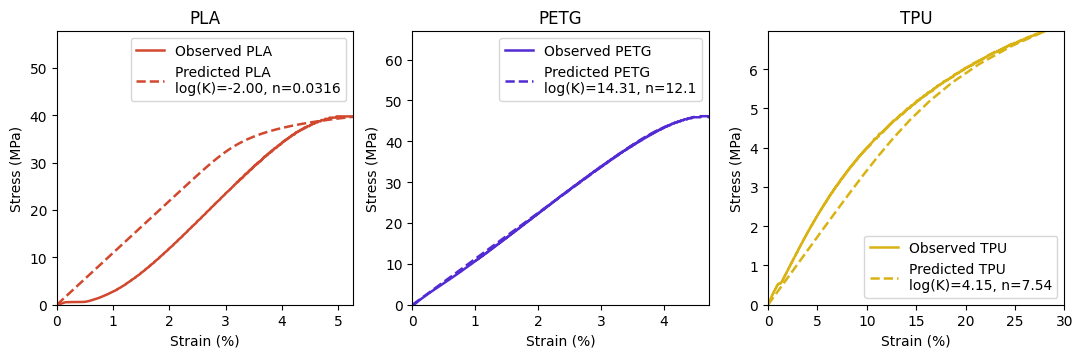

In [50]:
# Get the predicted stress and strain values for the elastic and early plastic regions based on the Ramberg-Osgood equation.
# Note that stress is plotted on Y-axis but is the input for the Ramberg-Osgood equation, while the strain is plotted on the X-axis but is the output.
list_RmOs_predictedStressValues = [np.linspace(0.0, stressPeak, 100) for stressPeak in list_UTMdata_stressPeak]
list_RmOS_predictedStrainValues = [func_RmOs_strainFunc(stressValues, elasticModulus, logK, N) for stressValues, elasticModulus, logK, N in zip(list_RmOs_predictedStressValues, list_UTMresult_elasticModulus,  list_UTMdata_RmOs_initLogKparam , list_UTMdata_RmOs_initNparam)]

# Set plotting parameters
param_plot_xlabel = "Strain (%)"
param_plot_ylabel = "Stress (MPa)"
param_plot_linewidth = 1.8

# Provide plots of each engineering stress-strain curve with the predicted curve of the Ramberg-Osgood equation
figure, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (13, 3.55))
plt.subplots_adjust(wspace = 0.2)

list_plotAxesRmOs = [ax1, ax2, ax3]

for UTMdata_strainEngg, UTMdata_stressEngg, RmOS_predictedStrainValues, RmOs_predictedStressValues, plotColor, name, strainRate, axisRmOs, val_logK, val_N in zip(list_UTMdata_strainEngg, list_UTMdata_stressEngg, list_RmOS_predictedStrainValues, list_RmOs_predictedStressValues, list_sample_plotColors, list_sample_names, list_sample_strainRates, list_plotAxesRmOs, list_UTMresult_RambergOsgood_logKConst, list_UTMresult_RambergOsgood_nConst):
    axisRmOs.plot(np.array(UTMdata_strainEngg)*100, np.array(UTMdata_stressEngg)/10**6, label = f"Observed {name}",
                  linewidth = param_plot_linewidth, color = plotColor, linestyle='-')
    axisRmOs.plot(np.array(RmOS_predictedStrainValues)*100, np.array(RmOs_predictedStressValues)/10**6, label = f"Predicted {name}\nlog(K)={val_logK:.2f}, n={val_N:.3}", linewidth = param_plot_linewidth, color = plotColor, linestyle='--')

# Set x and y axes labels
for axisRmOs, name in zip(list_plotAxesRmOs, list_sample_names):
    axisRmOs.set(xlabel=param_plot_xlabel, ylabel=param_plot_ylabel)
    axisRmOs.legend()
    axisRmOs.set_title(f"{name}")

# Set different x-limits and y-limits according to the selected range for the Ramberg-Osgood Equation
list_UTMdata_RmOsRangeStart = [0.0105, 0.00, 0.00]
list_UTMdata_RmOsRangeEnd = [0.0458, 0.0410, 1.00]
for axisRmOs, rangeStart, rangeEnd, stressYield in zip(list_plotAxesRmOs, list_UTMdata_RmOsRangeStart, list_UTMdata_RmOsRangeEnd, list_UTMresult_yieldStrength):
    axisRmOs.set_xlim(0, min(rangeEnd*100*1.15, 30.0))
    axisRmOs.set_ylim(0, stressYield/10**6*1.50)


### 6.3. Save data on the Ramberg-Osgood equation to a CSV file.

In [53]:
DF_UTMresults_RmOsEquation = pd.DataFrame({"Sample":list_sample_names,
                                           "Strain Start (%)": np.array(list_UTMdata_RmOsRangeStart)*100,
                                           "Strain End (%)": np.array(list_UTMdata_RmOsRangeEnd)*100,
                                           "log(K) Value":list_UTMresult_RambergOsgood_logKConst,
                                           "K Value":np.pow(10, np.array(list_UTMresult_RambergOsgood_logKConst)),
                                           "n Value:": list_UTMresult_RambergOsgood_nConst})
print(DF_UTMresults_RmOsEquation)
DF_UTMresults_RmOsEquation.to_csv("./Output_Data_Files/UTM_results_RambergOsgoodParams.csv", index=False)

  Sample  Strain Start (%)  Strain End (%)  log(K) Value       K Value  \
0    PLA              1.05            4.58     -1.995060  1.011440e-02   
1   PETG              0.00            4.10     14.306114  2.023549e+14   
2    TPU              0.00          100.00      4.149541  1.411046e+04   

    n Value:  
0   0.031569  
1  12.128385  
2   7.539178  
